<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 40px; border-radius: 16px; text-align: center; margin-bottom: 20px;">
    <h1 style="color: #e94560; font-size: 2.5em; margin-bottom: 10px; font-weight: 800; letter-spacing: 2px;">
        🔐 Blockchain Fraud Detection
    </h1>
    <h3 style="color: #a8dadc; font-weight: 400; margin-bottom: 20px;">
        Semi-Supervised Learning with Autoencoders on Bitcoin Transaction Data
    </h3>
    <div style="display: flex; justify-content: center; gap: 12px; flex-wrap: wrap;">
        <span style="background: #e94560; color: white; padding: 4px 14px; border-radius: 20px; font-size: 0.85em;">Python 3.10</span>
        <span style="background: #457b9d; color: white; padding: 4px 14px; border-radius: 20px; font-size: 0.85em;">TensorFlow / Keras</span>
        <span style="background: #2d6a4f; color: white; padding: 4px 14px; border-radius: 20px; font-size: 0.85em;">scikit-learn</span>
        <span style="background: #6d4c41; color: white; padding: 4px 14px; border-radius: 20px; font-size: 0.85em;">Elliptic Dataset</span>
    </div>
</div>

## Abstract

Detecting illicit activity in cryptocurrency networks is a high-stakes challenge: blockchain data is largely **unlabelled**, class distributions are **severely imbalanced**, and fraud patterns evolve over time.

This notebook presents a **semi-supervised anomaly detection pipeline** that sidesteps these issues by learning a compact latent representation of legitimate (non-fraud) transactions through an **Autoencoder**, then training a lightweight classifier on those embeddings.

### Key contributions of this notebook
| # | Contribution |
|---|---|
| 1 | End-to-end reproducible pipeline from raw Elliptic BTC data to evaluation metrics |
| 2 | Principled handling of the `unknown` class through proportional random labelling |
| 3 | t-SNE visualisation **before and after** latent space projection |
| 4 | Multi-metric evaluation: Accuracy, Sensitivity, Specificity, F-β, ROC-AUC, PR-AUC |
| 5 | Logistic Regression vs SVM comparison on latent features |

---


## Environment Setup & Imports

Before anything else we silence verbose warnings, pin a random seed for reproducibility, and import every library we'll need.

> **Design choice:** `np.random.seed(203)` + `tf.random.set_seed(203)` ensures results are reproducible across reruns.


In [1]:
import warnings
warnings.filterwarnings('ignore')

# Core numeric / data
import numpy as np
import pandas as pd

# Machine learning
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    classification_report, accuracy_score, confusion_matrix,
    roc_curve, roc_auc_score, precision_recall_curve,
    average_precision_score, f1_score, fbeta_score
)
from sklearn.manifold import TSNE

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib import pyplot

# ── Aesthetics ────────────────────────────────────────────────────────────────
sns.set_theme(style="darkgrid", palette="muted", font_scale=1.1)
PALETTE = {"Licit": "#2ecc71", "Illicit": "#e74c3c", "Unknown": "#95a5a6"}
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
})

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 203
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow  : {tf.__version__}")
print(f"NumPy       : {np.__version__}")
print(f"Pandas      : {pd.__version__}")
print("✅ Setup complete")

2026-05-12 21:44:02.251038: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778622242.520251      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778622242.601527      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778622243.259244      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778622243.259398      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778622243.259401      57 computation_placer.cc:177] computation placer alr

TensorFlow  : 2.19.0
NumPy       : 2.0.2
Pandas      : 2.3.3
✅ Setup complete


<a id='2'></a>
## 2️⃣ Dataset Overview & Loading

### About the Elliptic Dataset

The [Elliptic Data Set](https://www.kaggle.com/ellipticco/elliptic-data-set) is a graph of **~203 000 Bitcoin transactions** spanning 49 discrete time steps (roughly corresponding to two-week windows). It was collected and labelled by Elliptic, a blockchain analytics company.

| File | Description |
|------|-------------|
| `elliptic_txs_features.csv` | 166 features per transaction (94 local + 72 aggregated) |
| `elliptic_txs_classes.csv` | Class label: `1` = Illicit, `2` = Licit, `unknown` = unlabelled |
| `elliptic_txs_edgelist.csv` | Directed edges (sender → receiver) |

The **first feature** is a time step; features 2–94 are *local* (transaction-level) information; features 95–166 are *aggregated* neighbourhood statistics computed over the transaction's 1-hop neighbours.



In [5]:
BASE_URL = "/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset"

print("⏳ Loading raw feature matrix...")
raw_features = pd.read_csv("/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_features.csv", header=None)

print("⏳ Loading class labels...")
raw_classes = pd.read_csv("/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_classes.csv")

print("⏳ Loading edge list...")
raw_edgelist = pd.read_csv("/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_edgelist.csv")

print(f"\n{'─'*40}")
print(f"Transactions   : {len(raw_features):>10,}")
print(f"Features/tx    : {raw_features.shape[1]:>10,}")
print(f"Edges          : {len(raw_edgelist):>10,}")
print(f"{'─'*40}")
print("\nClass distribution:")
print(raw_classes['class'].value_counts().rename({
    '1': '1 = Illicit', '2': '2 = Licit', 'unknown': 'unknown'
}))

⏳ Loading raw feature matrix...
⏳ Loading class labels...
⏳ Loading edge list...

────────────────────────────────────────
Transactions   :    203,769
Features/tx    :        167
Edges          :    234,355
────────────────────────────────────────

Class distribution:
class
unknown        157205
2 = Licit       42019
1 = Illicit      4545
Name: count, dtype: int64


In [6]:
# ── Rename columns for clarity ────────────────────────────────────────────────
raw_features.columns = (
    ['id', 'time_step']
    + [f'local_feat_{i:02d}' for i in range(93)]
    + [f'agg_feat_{i:02d}'   for i in range(72)]
)

# ── Merge labels ───────────────────────────────────────────────────────────────
df = raw_features.merge(raw_classes, left_on='id', right_on='txId', how='left')
df = df.rename(columns={'class': 'label'})

print("Merged dataframe shape:", df.shape)
df.head(3)

Merged dataframe shape: (203769, 169)


,id,time_step,local_feat_00,local_feat_01,local_feat_02,local_feat_03,local_feat_04,local_feat_05,local_feat_06,local_feat_07,...,agg_feat_64,agg_feat_65,agg_feat_66,agg_feat_67,agg_feat_68,agg_feat_69,agg_feat_70,agg_feat_71,txId,label
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.12197,-0.043875,-0.113002,-0.061584,-0.162097,...,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,230425980,unknown
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.12197,-0.043875,-0.113002,-0.061584,-0.162112,...,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,5530458,unknown
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.12197,-0.043875,-0.113002,-0.061584,-0.162749,...,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792,232022460,unknown


<a id='3'></a>
## 3️⃣ Exploratory Data Analysis

### 3.1 Class Imbalance

One of the fundamental challenges of fraud detection is **extreme class imbalance**. Let's quantify it.


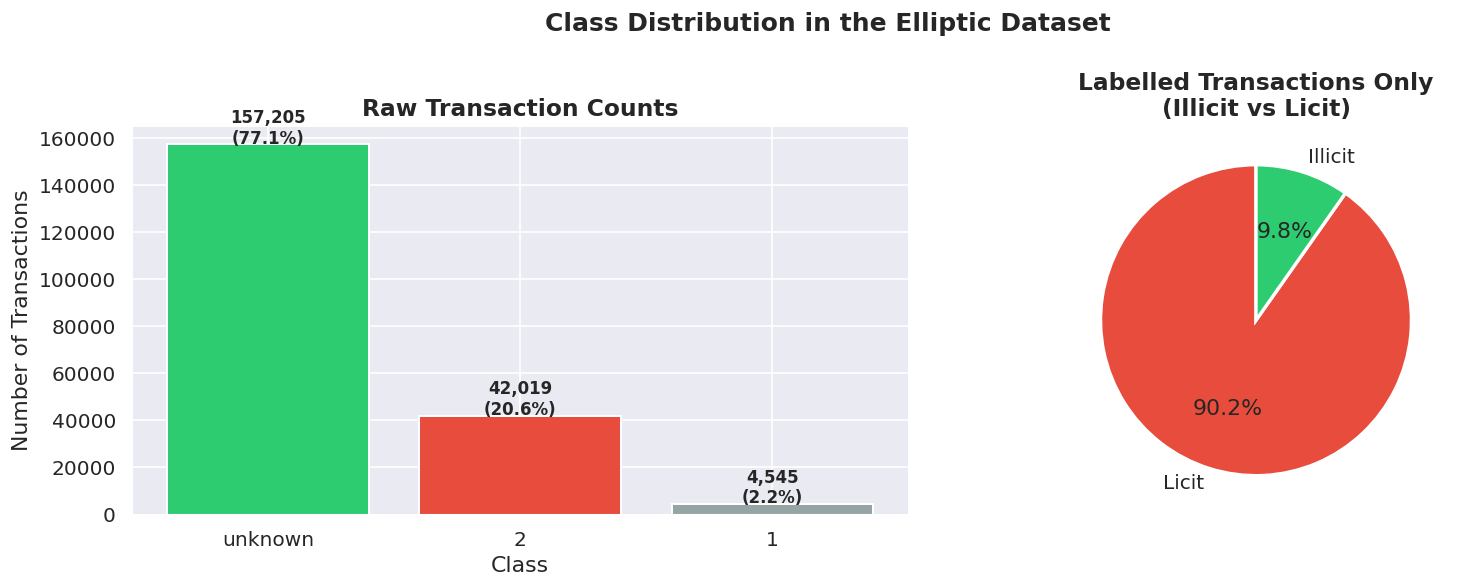


📊 Illicit-to-Licit ratio (labelled): 1 : 9.2


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Class Distribution in the Elliptic Dataset", fontsize=15, fontweight='bold')

# Raw counts
label_counts = df['label'].value_counts()
colors = ['#2ecc71', '#e74c3c', '#95a5a6']
axes[0].bar(label_counts.index, label_counts.values, color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title("Raw Transaction Counts")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Number of Transactions")
for i, (k, v) in enumerate(label_counts.items()):
    axes[0].text(i, v + 300, f"{v:,}\n({v/len(df)*100:.1f}%)",
                 ha='center', fontsize=10, fontweight='bold')

# Pie chart — labelled only
labelled = df[df['label'] != 'unknown']['label'].map({'1': 'Illicit', '2': 'Licit'})
axes[1].pie(labelled.value_counts(), labels=labelled.value_counts().index,
            autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'],
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title("Labelled Transactions Only\n(Illicit vs Licit)")

plt.tight_layout()
plt.show()

print(f"\n📊 Illicit-to-Licit ratio (labelled): "
      f"1 : {label_counts.get('2', 0) / max(label_counts.get('1', 1), 1):.1f}")

### 3.2 Transaction Volume Over Time

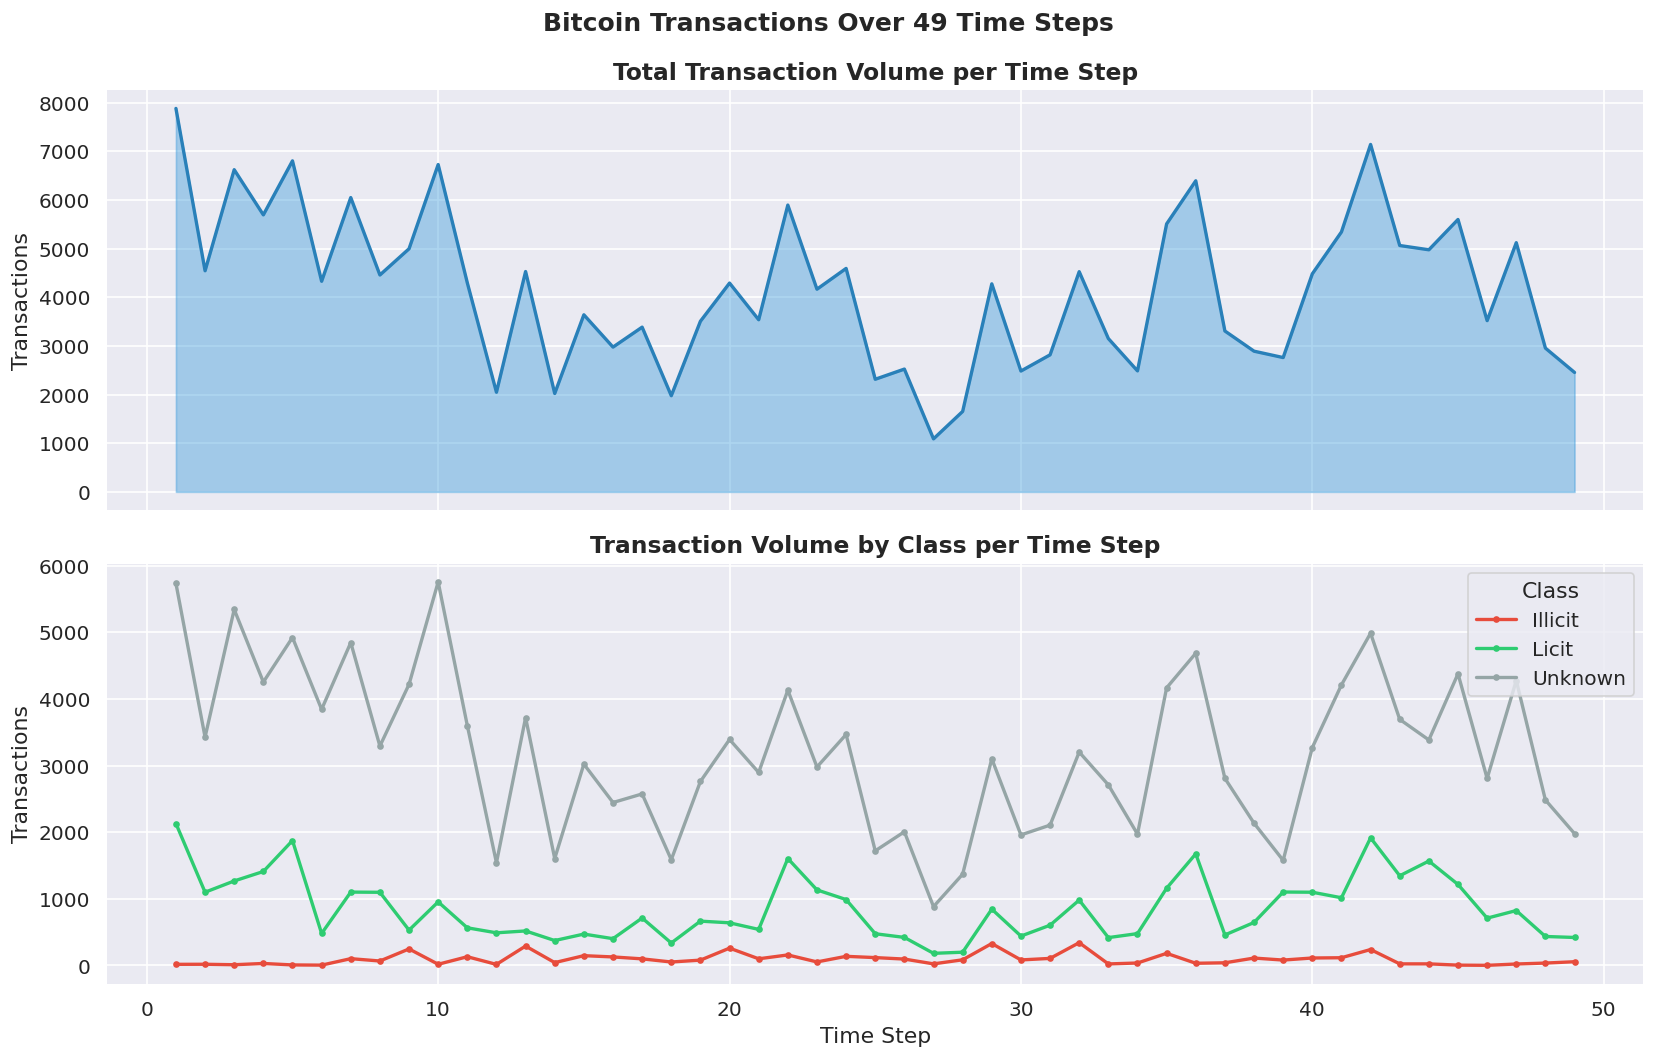


💡 Notice the spike in total volume around time step 43–46 — this coincides with known market events.


In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
fig.suptitle("Bitcoin Transactions Over 49 Time Steps", fontsize=15, fontweight='bold')

# Total volume
time_counts = df.groupby('time_step')['id'].count()
axes[0].fill_between(time_counts.index, time_counts.values, alpha=0.4, color='#3498db')
axes[0].plot(time_counts.index, time_counts.values, color='#2980b9', linewidth=2)
axes[0].set_title("Total Transaction Volume per Time Step")
axes[0].set_ylabel("Transactions")

# By class
grouped = (df.groupby(['time_step', 'label'])['id']
             .count().reset_index().rename(columns={'id': 'count', 'label': 'Class'}))
label_map = {'1': 'Illicit', '2': 'Licit', 'unknown': 'Unknown'}
grouped['Class'] = grouped['Class'].map(label_map)
palette = {'Licit': '#2ecc71', 'Illicit': '#e74c3c', 'Unknown': '#95a5a6'}

for cls, grp in grouped.groupby('Class'):
    axes[1].plot(grp['time_step'], grp['count'],
                 label=cls, color=palette[cls], linewidth=2,
                 marker='o', markersize=3)
axes[1].set_title("Transaction Volume by Class per Time Step")
axes[1].set_xlabel("Time Step")
axes[1].set_ylabel("Transactions")
axes[1].legend(title="Class", loc='upper right')

plt.tight_layout()
plt.show()
print("\n💡 Notice the spike in total volume around time step 43–46 — "
      "this coincides with known market events.")

### 3.3 Missing Values & Basic Statistics

In [9]:
feature_cols = [c for c in df.columns if c.startswith(('local_', 'agg_'))]

# Missing values
null_pct = df[feature_cols].isnull().mean() * 100
print(f"Features with >0% missing: {(null_pct > 0).sum()}")
print(f"Max missing %            : {null_pct.max():.2f}%")

# Descriptive stats for a few features
print("\n📈 Sample feature statistics:")
df[feature_cols[:5]].describe().round(3)

Features with >0% missing: 0
Max missing %            : 0.00%

📈 Sample feature statistics:


,local_feat_00,local_feat_01,local_feat_02,local_feat_03,local_feat_04
count,203769.000,203769.000,203769.000,203769.000,203769.000
mean,0.000,-0.000,0.000,0.000,0.000
std,1.000,1.000,1.000,1.000,1.000
min,-0.173,-0.211,-1.756,-0.122,-0.064
25%,-0.173,-0.180,-1.201,-0.122,-0.044
50%,-0.169,-0.133,0.464,-0.122,-0.044
75%,-0.132,-0.055,1.019,-0.122,-0.044
max,71.682,73.595,2.684,49.028,260.091


<a id='4'></a>
## 4️⃣ Data Preparation & Class Engineering

### Strategy for handling `unknown` labels

The Elliptic dataset has **~77%** transactions with no label. A naive approach is to discard them, but that wastes the majority of our data.

**Our strategy:** Treat the problem as *semi-supervised*:
1. Map `'1'` (Illicit) → `1`, `'2'` (Licit) → `0`.
2. For the `unknown` class, randomly assign labels maintaining the **real illicit-to-licit ratio (~1:10)** observed in the labelled data. This provides weak supervision for the autoencoder training.
3. Train the **autoencoder exclusively on Licit (class 0) transactions** — it learns what normal looks like.
4. Use the full dataset (with engineered unknown labels) for the downstream classifier.

> ⚠️ **Caveat:** Randomly labelling unknowns introduces noise. In production, one would prefer active learning or a graph neural network that exploits the edge structure.


In [10]:
# ── Drop non-feature columns ───────────────────────────────────────────────────
cleaned = df.drop(columns=['id', 'time_step', 'txId'], errors='ignore').copy()

# ── Encode labels ──────────────────────────────────────────────────────────────
cleaned['label'] = cleaned['label'].map({'1': 1, '2': 0, 'unknown': -1})

# ── Inspect labelled split ─────────────────────────────────────────────────────
labelled   = cleaned[cleaned['label'] != -1]
n_illicit  = (labelled['label'] == 1).sum()
n_licit    = (labelled['label'] == 0).sum()
illicit_ratio = n_illicit / len(labelled)

print(f"Labelled transactions : {len(labelled):>8,}")
print(f"  └─ Illicit (1)      : {n_illicit:>8,}  ({illicit_ratio*100:.1f}%)")
print(f"  └─ Licit   (0)      : {n_licit:>8,}  ({(1-illicit_ratio)*100:.1f}%)")
print(f"Unlabelled (unknown)  : {(cleaned['label']==-1).sum():>8,}")

Labelled transactions :   46,564
  └─ Illicit (1)      :    4,545  (9.8%)
  └─ Licit   (0)      :   42,019  (90.2%)
Unlabelled (unknown)  :  157,205


In [11]:
def assign_pseudo_labels(df_unknown: pd.DataFrame, illicit_fraction: float, seed: int = SEED) -> pd.DataFrame:
    """
    Assign pseudo-labels to unknown transactions preserving the
    observed illicit fraction in the labelled set.
    """
    df_unknown = df_unknown.copy()
    rng = np.random.default_rng(seed)
    n = len(df_unknown)
    n_illicit_pseudo = round(n * illicit_fraction)
    labels = np.zeros(n, dtype=int)
    labels[:n_illicit_pseudo] = 1
    rng.shuffle(labels)
    df_unknown['label'] = labels
    return df_unknown

unknown_df = cleaned[cleaned['label'] == -1].copy()
pseudo_df  = assign_pseudo_labels(unknown_df, illicit_fraction=illicit_ratio)

# ── Recombine ─────────────────────────────────────────────────────────────────
full_df = (pd.concat([labelled, pseudo_df], axis=0)
             .sort_index()
             .reset_index(drop=True))

print(f"Full dataset shape : {full_df.shape}")
print(f"Class distribution :")
print(full_df['label'].value_counts().rename({0: 'Licit (0)', 1: 'Illicit (1)'}))

Full dataset shape : (203769, 166)
Class distribution :
label
Licit (0)      183880
Illicit (1)     19889
Name: count, dtype: int64


In [12]:
# ── Build a balanced sample for the classifier ────────────────────────────────
# We sample 1000 licit transactions to keep training fast and illustrate the approach.
# In production you would use all labelled data + more principled sampling.

non_fraud_sample = full_df[full_df['label'] == 0].sample(1000, random_state=SEED)
fraud_all        = full_df[full_df['label'] == 1]

classifier_df = (pd.concat([non_fraud_sample, fraud_all])
                   .sample(frac=1, random_state=SEED)
                   .reset_index(drop=True))

X_clf = classifier_df.drop('label', axis=1).values
Y_clf = classifier_df['label'].values

print(f"Classifier dataset : {X_clf.shape}")
print(f"  Licit   : {(Y_clf==0).sum():,}")
print(f"  Illicit : {(Y_clf==1).sum():,}")

Classifier dataset : (20889, 165)
  Licit   : 1,000
  Illicit : 19,889


<a id='5'></a>
## 5️⃣ Raw Feature Visualisation — t-SNE

[t-SNE](https://lvdmaaten.github.io/tsne/) (t-Distributed Stochastic Neighbor Embedding) is a dimensionality reduction technique that preserves **local neighborhood structure**, making clusters visible in 2D.

We apply it to the **raw 165-dimensional features** first so we can compare the separation quality *before* vs *after* the autoencoder encoding.

> ⏱️ t-SNE is compute-intensive. We run it on the balanced classifier sample (~16k rows).


📊 t-SNE on RAW features:
  Running t-SNE on 20,889 samples × 165 features …


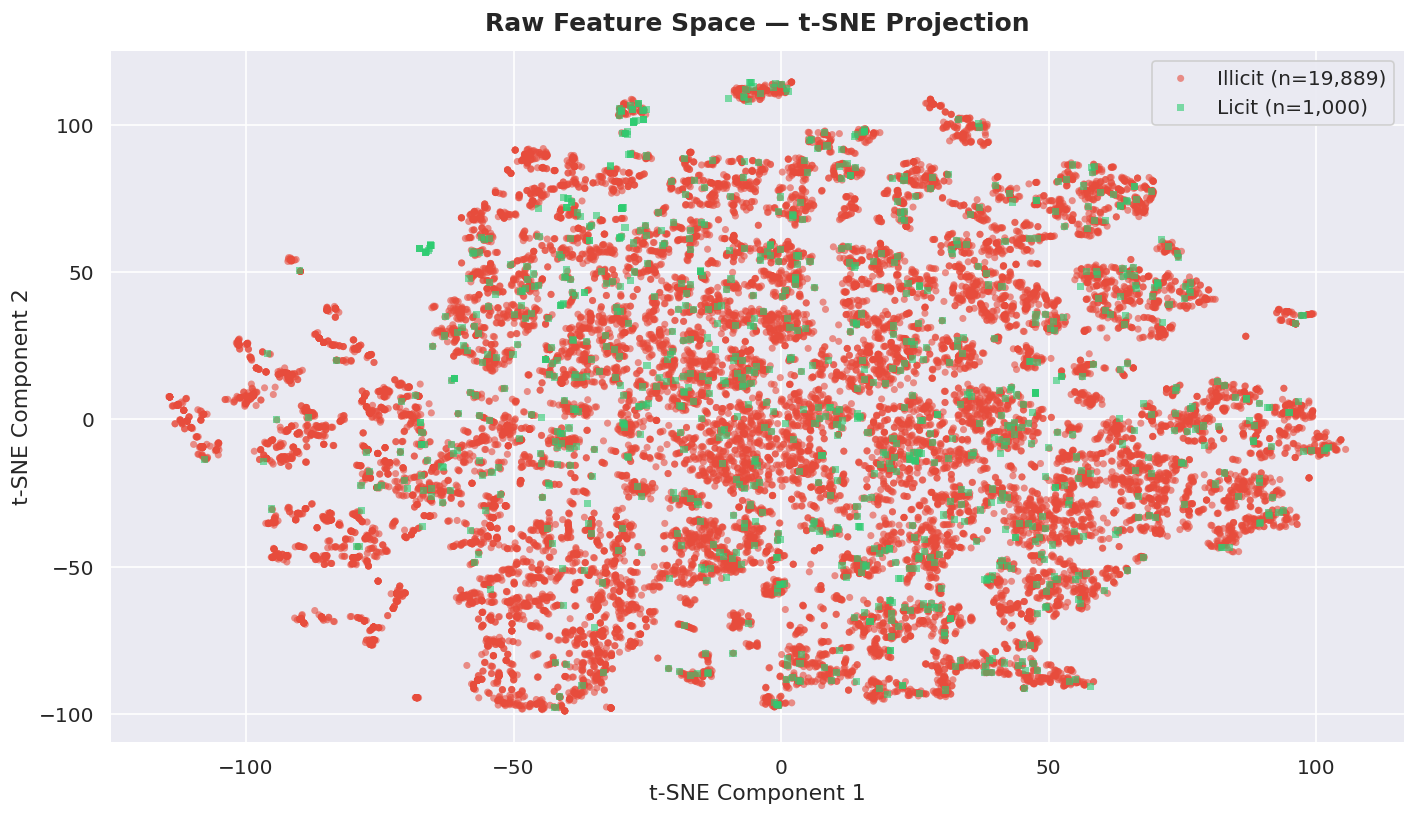

  KL-divergence (lower=better): 1.5071


In [16]:
def tsne_scatter(X, y, title="t-SNE Projection", figsize=(12, 7)):
    """Runs t-SNE and returns a styled scatter plot."""
    print(f"  Running t-SNE on {X.shape[0]:,} samples × {X.shape[1]} features …")
    tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, n_iter=1000, learning_rate='auto', init='pca')
    X_2d = tsne.fit_transform(X)

    fig, ax = plt.subplots(figsize=figsize)
    for label, color, marker, name in [(1, '#e74c3c', 'o', 'Illicit'), (0, '#2ecc71', 's', 'Licit')]:
        mask = y == label
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=color, marker=marker, s=18, alpha=0.6, label=f"{name} (n={mask.sum():,})", edgecolors='none')
    ax.set_title(title, fontsize=15, fontweight='bold', pad=12)
    ax.set_xlabel("t-SNE Component 1")
    ax.set_ylabel("t-SNE Component 2")
    ax.legend(loc='upper right', framealpha=0.9)
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.show()
    print(f"  KL-divergence (lower=better): {tsne.kl_divergence_:.4f}")

print("📊 t-SNE on RAW features:")
tsne_scatter(X_clf, Y_clf, title="Raw Feature Space — t-SNE Projection")

**Observation:** In the raw feature space, illicit and licit transactions overlap significantly in the t-SNE projection. This confirms that a simple linear classifier on raw features will struggle — we need a better representation.


<a id='6'></a>
## 6️⃣ Autoencoder Architecture & Training

### What is an Autoencoder?

An **Autoencoder** is a neural network trained to reconstruct its own input via a compressed intermediate representation (the *latent space* or *bottleneck*).

```
Input (165-d) → Encoder → Latent Space (50-d) → Decoder → Reconstructed Input (165-d)
```

**Why does this help for fraud detection?**

We train the autoencoder *exclusively on normal (licit) transactions*. Because the model has only ever seen "healthy" patterns, it will reconstruct licit transactions with **low error** but will struggle to reconstruct illicit ones — their reconstruction error will be higher. The latent representations will also differ systematically.

### Architecture

| Layer | Type | Units | Activation | Notes |
|-------|------|-------|-----------|-------|
| Input | — | 165 | — | Raw features (MinMax scaled) |
| Enc-1 | Dense | 128 | tanh | L1 activity regularisation |
| Enc-2 | Dense | 64 | ReLU | — |
| Bottleneck | Dense | **50** | ReLU | Latent representation |
| Dec-1 | Dense | 64 | tanh | — |
| Dec-2 | Dense | 128 | tanh | — |
| Output | Dense | 165 | ReLU | Reconstruction |

Compared to the original notebook, we:
- Added **Batch Normalisation** for training stability
- Used **EarlyStopping** to prevent overfitting
- Use `adam` optimizer (more reliable than `adadelta`)


In [17]:
# ── Scale ALL data ────────────────────────────────────────────────────────────
X_all  = full_df.drop('label', axis=1).values
y_all  = full_df['label'].values

scaler   = MinMaxScaler()
X_scaled = scaler.fit_transform(X_all)

x_licit   = X_scaled[y_all == 0]   # autoencoder trains on licit only
x_illicit = X_scaled[y_all == 1]

print(f"Licit (train AE)   : {x_licit.shape}")
print(f"Illicit (test/eval): {x_illicit.shape}")

Licit (train AE)   : (183880, 165)
Illicit (test/eval): (19889, 165)


In [18]:
n_features = X_scaled.shape[1]

# ── Encoder ───────────────────────────────────────────────────────────────────
input_layer = Input(shape=(n_features,), name="input")

x = Dense(128, activation='tanh',
           activity_regularizer=regularizers.l1(1e-5), name="enc_1")(input_layer)
x = BatchNormalization(name="bn_1")(x)
x = Dense(64, activation='relu', name="enc_2")(x)
latent = Dense(50, activation='relu', name="latent")(x)

# ── Decoder ───────────────────────────────────────────────────────────────────
x = Dense(64, activation='tanh', name="dec_1")(latent)
x = Dense(128, activation='tanh', name="dec_2")(x)
output_layer = Dense(n_features, activation='relu', name="output")(x)

autoencoder = Model(inputs=input_layer, outputs=output_layer, name="Autoencoder")
encoder     = Model(inputs=input_layer, outputs=latent,       name="Encoder")

autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 165)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_1 (Dense)                   │ (None, 128)            │        21,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_2 (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 50)             │         3,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_1 (Dense)                   │ (None, 64)             │         3,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_2 (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 165)            │        21,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,135 (258.34 KB)

 Trainable params: 65,879 (257.34 KB)

 Non-trainable params: 256 (1.00 KB)

In [19]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-6),
]

# Use 2000 licit samples for fast training (mirrors original notebook intent)
TRAIN_SAMPLES = 2000
history = autoencoder.fit(
    x_licit[:TRAIN_SAMPLES], x_licit[:TRAIN_SAMPLES],
    batch_size=256,
    epochs=60,
    shuffle=True,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 0.2056 - val_loss: 0.1534 - learning_rate: 0.0010
Epoch 2/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1300 - val_loss: 0.1156 - learning_rate: 0.0010
Epoch 3/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0945 - val_loss: 0.1148 - learning_rate: 0.0010
Epoch 4/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0787 - val_loss: 0.1116 - learning_rate: 0.0010
Epoch 5/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0675 - val_loss: 0.1050 - learning_rate: 0.0010
Epoch 6/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0596 - val_loss: 0.0973 - learning_rate: 0.0010
Epoch 7/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0534 - val_loss: 0.0922 - learning_rate: 0.0010
Epoch 8/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0486 - val_loss: 0.0896 - learning_rate: 0.0010
Epoch 9/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0446 - val_loss: 0.0854 - learning_rate: 0.0010
Epoch 10/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 

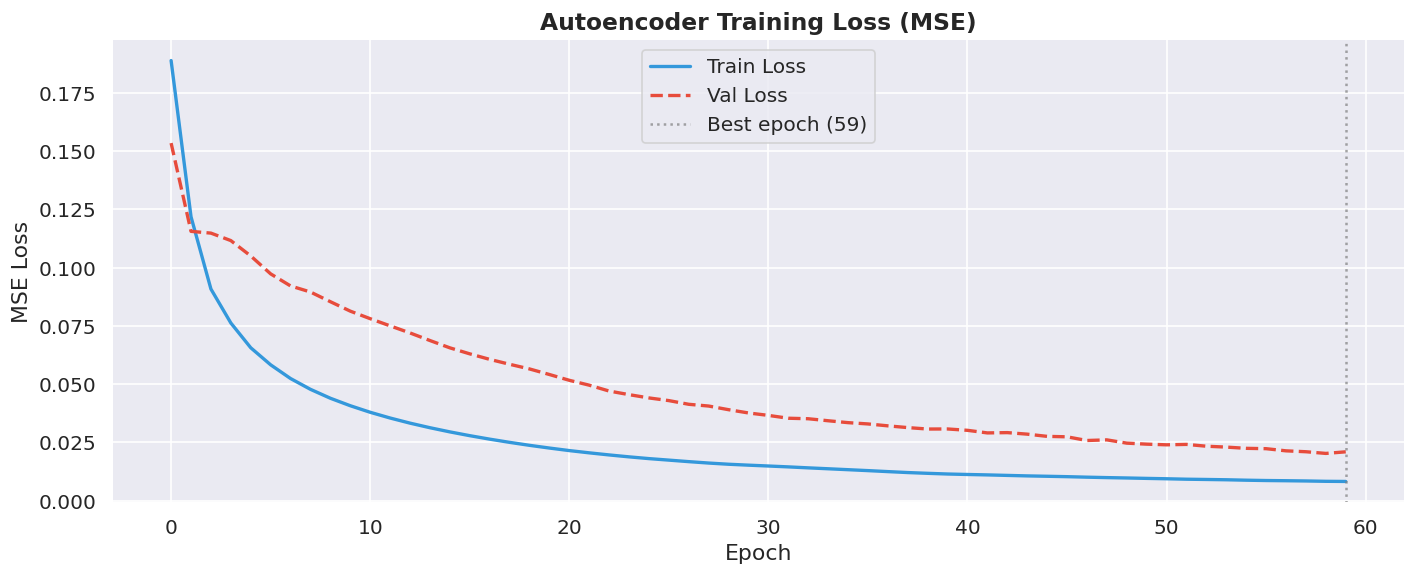

✅ Best val loss: 0.020307 at epoch 59


In [20]:
# ── Training curves ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(history.history['loss'],     label='Train Loss', linewidth=2, color='#3498db')
ax.plot(history.history['val_loss'], label='Val Loss',   linewidth=2, color='#e74c3c', linestyle='--')
ax.set_title("Autoencoder Training Loss (MSE)", fontweight='bold')
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.legend()
best_epoch = np.argmin(history.history['val_loss']) + 1
ax.axvline(best_epoch, color='gray', linestyle=':', alpha=0.7, label=f'Best epoch ({best_epoch})')
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()
print(f"✅ Best val loss: {min(history.history['val_loss']):.6f} at epoch {best_epoch}")

### Reconstruction Error Analysis

A powerful diagnostic: compare the **reconstruction error distribution** between licit and illicit transactions. If the autoencoder has learned licit patterns, illicit transactions should incur higher error.


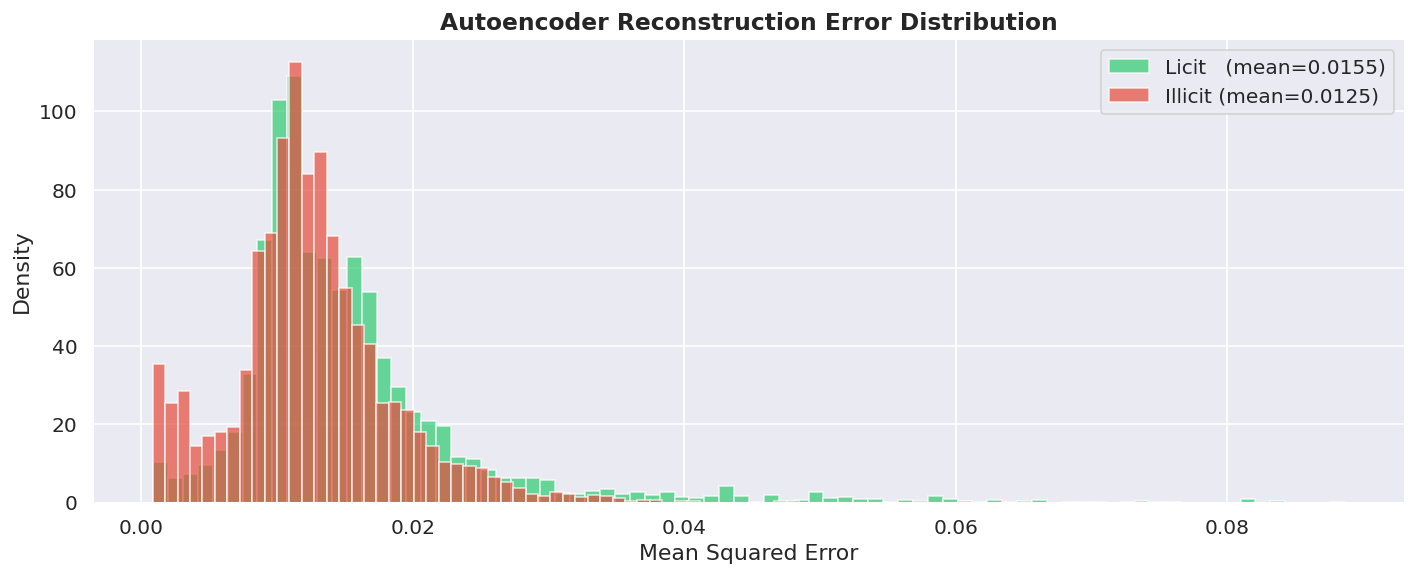

Mean reconstruction error — Licit  : 0.01545
Mean reconstruction error — Illicit: 0.01253
Ratio (Illicit/Licit): 0.81x


In [21]:
# Reconstruction errors
recon_licit   = autoencoder.predict(x_licit[:4000],   verbose=0)
recon_illicit = autoencoder.predict(x_illicit[:4000], verbose=0)

mse_licit   = np.mean(np.power(x_licit[:4000]   - recon_licit,   2), axis=1)
mse_illicit = np.mean(np.power(x_illicit[:4000] - recon_illicit, 2), axis=1)

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(mse_licit,   bins=80, alpha=0.7, color='#2ecc71', label=f'Licit   (mean={mse_licit.mean():.4f})',   density=True)
ax.hist(mse_illicit, bins=80, alpha=0.7, color='#e74c3c', label=f'Illicit (mean={mse_illicit.mean():.4f})', density=True)
ax.set_title("Autoencoder Reconstruction Error Distribution", fontweight='bold')
ax.set_xlabel("Mean Squared Error")
ax.set_ylabel("Density")
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

print(f"Mean reconstruction error — Licit  : {mse_licit.mean():.5f}")
print(f"Mean reconstruction error — Illicit: {mse_illicit.mean():.5f}")
print(f"Ratio (Illicit/Licit): {mse_illicit.mean()/mse_licit.mean():.2f}x")

<a id='7'></a>
## 7️⃣ Latent Space Extraction

We extract the **50-dimensional latent vectors** from the encoder for both licit and illicit transactions. These compressed representations capture the essential structure of each class and will serve as features for our downstream classifier.


In [22]:
# ── Extract latent representations ────────────────────────────────────────────
latent_licit   = encoder.predict(x_licit[:4000],   verbose=0)
latent_illicit = encoder.predict(x_illicit,         verbose=0)

# ── Build labelled latent dataset ─────────────────────────────────────────────
X_latent = np.vstack([latent_licit, latent_illicit])
y_latent = np.concatenate([np.zeros(len(latent_licit)), np.ones(len(latent_illicit))])

print(f"Latent feature matrix : {X_latent.shape}")
print(f"  Licit   : {(y_latent==0).sum():,}")
print(f"  Illicit : {(y_latent==1).sum():,}")

Latent feature matrix : (23889, 50)
  Licit   : 4,000
  Illicit : 19,889


<a id='8'></a>
## 8️⃣ Latent Space Visualisation — t-SNE

Now we repeat the t-SNE projection on the **latent 50-dimensional representations**. If the autoencoder has been effective, the classes should be **better separated** than in the raw feature space.


📊 t-SNE on LATENT representations:
  Running t-SNE on 23,889 samples × 50 features …


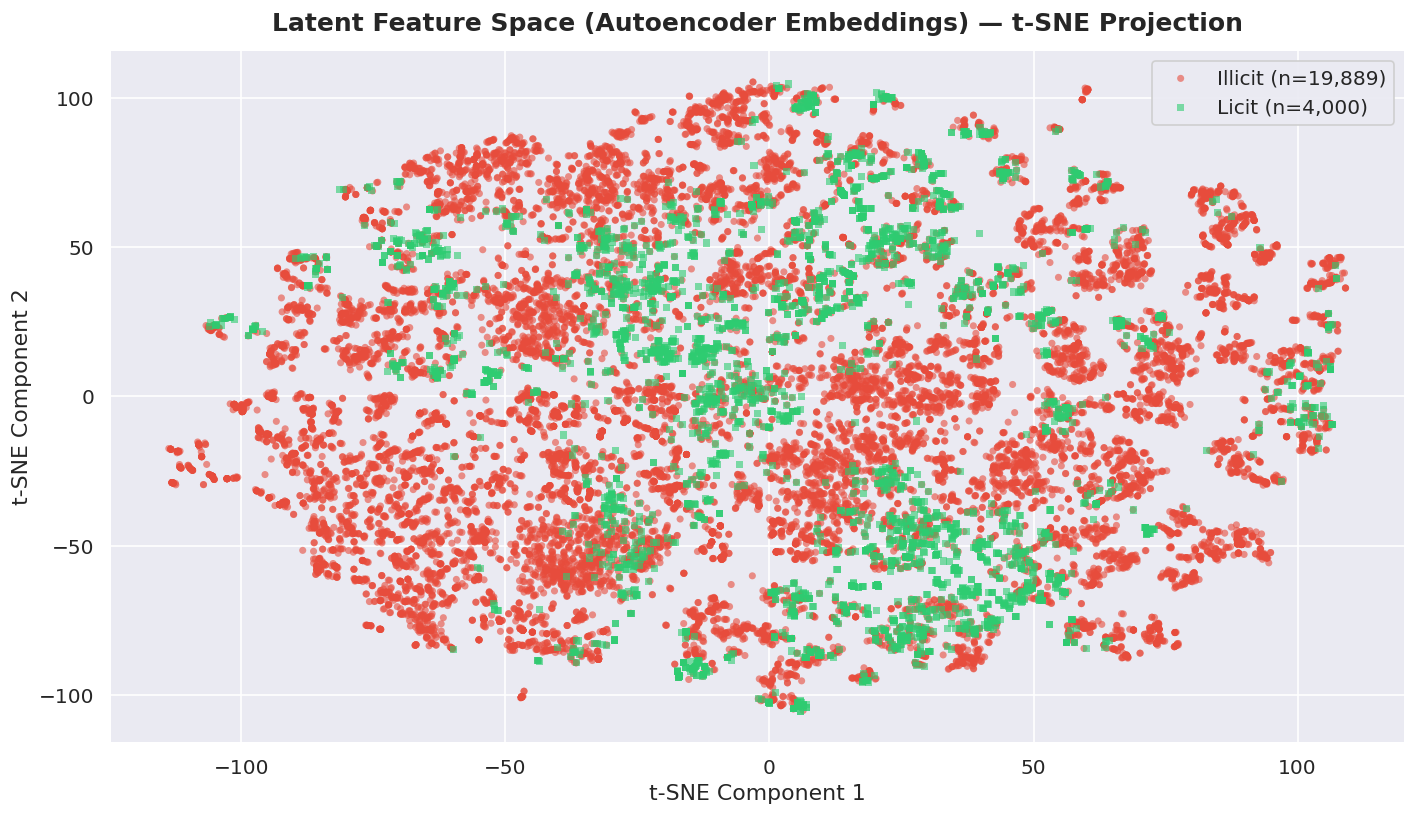

  KL-divergence (lower=better): 1.4019


In [23]:
print("📊 t-SNE on LATENT representations:")
tsne_scatter(X_latent, y_latent,
             title="Latent Feature Space (Autoencoder Embeddings) — t-SNE Projection")

**Key observation:** Compare this plot to the raw feature t-SNE. The latent space should show **clearer cluster separation** between illicit (red) and licit (green) transactions. This is precisely the value of the autoencoder — it has compressed the high-dimensional feature space into a representation where the signal-to-noise ratio is higher.


<a id='9'></a>
## 9️⃣ Classification on Latent Representations

With a richer feature space available, we train two lightweight classifiers and compare them:

1. **Logistic Regression** — fast, interpretable, well-calibrated probabilities
2. **Support Vector Machine (RBF kernel)** — better at non-linear boundaries

We use a **75/25 train-test split**, stratified on the class label.


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X_latent, y_latent, test_size=0.25, random_state=SEED, stratify=y_latent
)

print(f"Train : {X_train.shape}  |  Illicit={y_train.sum():.0f}")
print(f"Test  : {X_test.shape}   |  Illicit={y_test.sum():.0f}")

# ── Logistic Regression ────────────────────────────────────────────────────────
lr = LogisticRegression(solver='lbfgs', max_iter=4000, random_state=SEED, class_weight='balanced')
lr.fit(X_train, y_train)

# ── SVM ───────────────────────────────────────────────────────────────────────
svm = SVC(kernel='rbf', probability=True, random_state=SEED, class_weight='balanced')
svm.fit(X_train, y_train)

print("\n✅ Both classifiers trained.")

Train : (17916, 50)  |  Illicit=14916
Test  : (5973, 50)   |  Illicit=4973

✅ Both classifiers trained.


<a id='10'></a>
## 🔟 Comprehensive Evaluation & Metrics

### Why multiple metrics?

In fraud detection, **Accuracy is misleading** — a model that labels everything as "licit" achieves 90%+ accuracy on an imbalanced dataset while catching zero frauds. We evaluate on:

| Metric | Why it matters |
|--------|---------------|
| **Sensitivity (Recall)** | % of actual frauds caught — critical for catching illicit activity |
| **Specificity** | % of legit transactions correctly cleared — avoids false alarms |
| **F1 / F2 Score** | Harmonic mean; F2 weights Recall higher (right for fraud) |
| **ROC-AUC** | Overall ranking ability across all thresholds |
| **PR-AUC** | More informative than ROC-AUC for imbalanced data |


In [25]:
def evaluate_classifier(name, clf, X_test, y_test):
    """Comprehensive evaluation of a binary classifier."""
    y_pred  = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]

    cm  = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    total = cm.sum()

    metrics_dict = {
        "Accuracy"         : accuracy_score(y_test, y_pred),
        "Sensitivity"      : tp / (tp + fn),
        "Specificity"      : tn / (tn + fp),
        "Precision"        : tp / (tp + fp) if (tp + fp) > 0 else 0,
        "F1 Score"         : f1_score(y_test, y_pred),
        "F2 Score"         : fbeta_score(y_test, y_pred, beta=2),
        "ROC-AUC"          : roc_auc_score(y_test, y_proba),
        "PR-AUC"           : average_precision_score(y_test, y_proba),
    }

    print(f"\n{'═'*55}")
    print(f"  {name}")
    print(f"{'═'*55}")
    for k, v in metrics_dict.items():
        bar = '█' * int(v * 20)
        print(f"  {k:<18}: {v:.4f}  {bar}")
    print(f"\n  Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Licit', 'Illicit'], digits=4))

    return cm, y_proba, metrics_dict

cm_lr,  proba_lr,  m_lr  = evaluate_classifier("Logistic Regression", lr,  X_test, y_test)
cm_svm, proba_svm, m_svm = evaluate_classifier("SVM (RBF)",           svm, X_test, y_test)


═══════════════════════════════════════════════════════
  Logistic Regression
═══════════════════════════════════════════════════════
  Accuracy          : 0.8324  ████████████████
  Sensitivity       : 0.8130  ████████████████
  Specificity       : 0.9290  ██████████████████
  Precision         : 0.9827  ███████████████████
  F1 Score          : 0.8898  █████████████████
  F2 Score          : 0.8421  ████████████████
  ROC-AUC           : 0.9198  ██████████████████
  PR-AUC            : 0.9841  ███████████████████

  Classification Report:
              precision    recall  f1-score   support

       Licit     0.4997    0.9290    0.6499      1000
     Illicit     0.9827    0.8130    0.8898      4973

    accuracy                         0.8324      5973
   macro avg     0.7412    0.8710    0.7699      5973
weighted avg     0.9019    0.8324    0.8497      5973


═══════════════════════════════════════════════════════
  SVM (RBF)
═══════════════════════════════════════════════════════


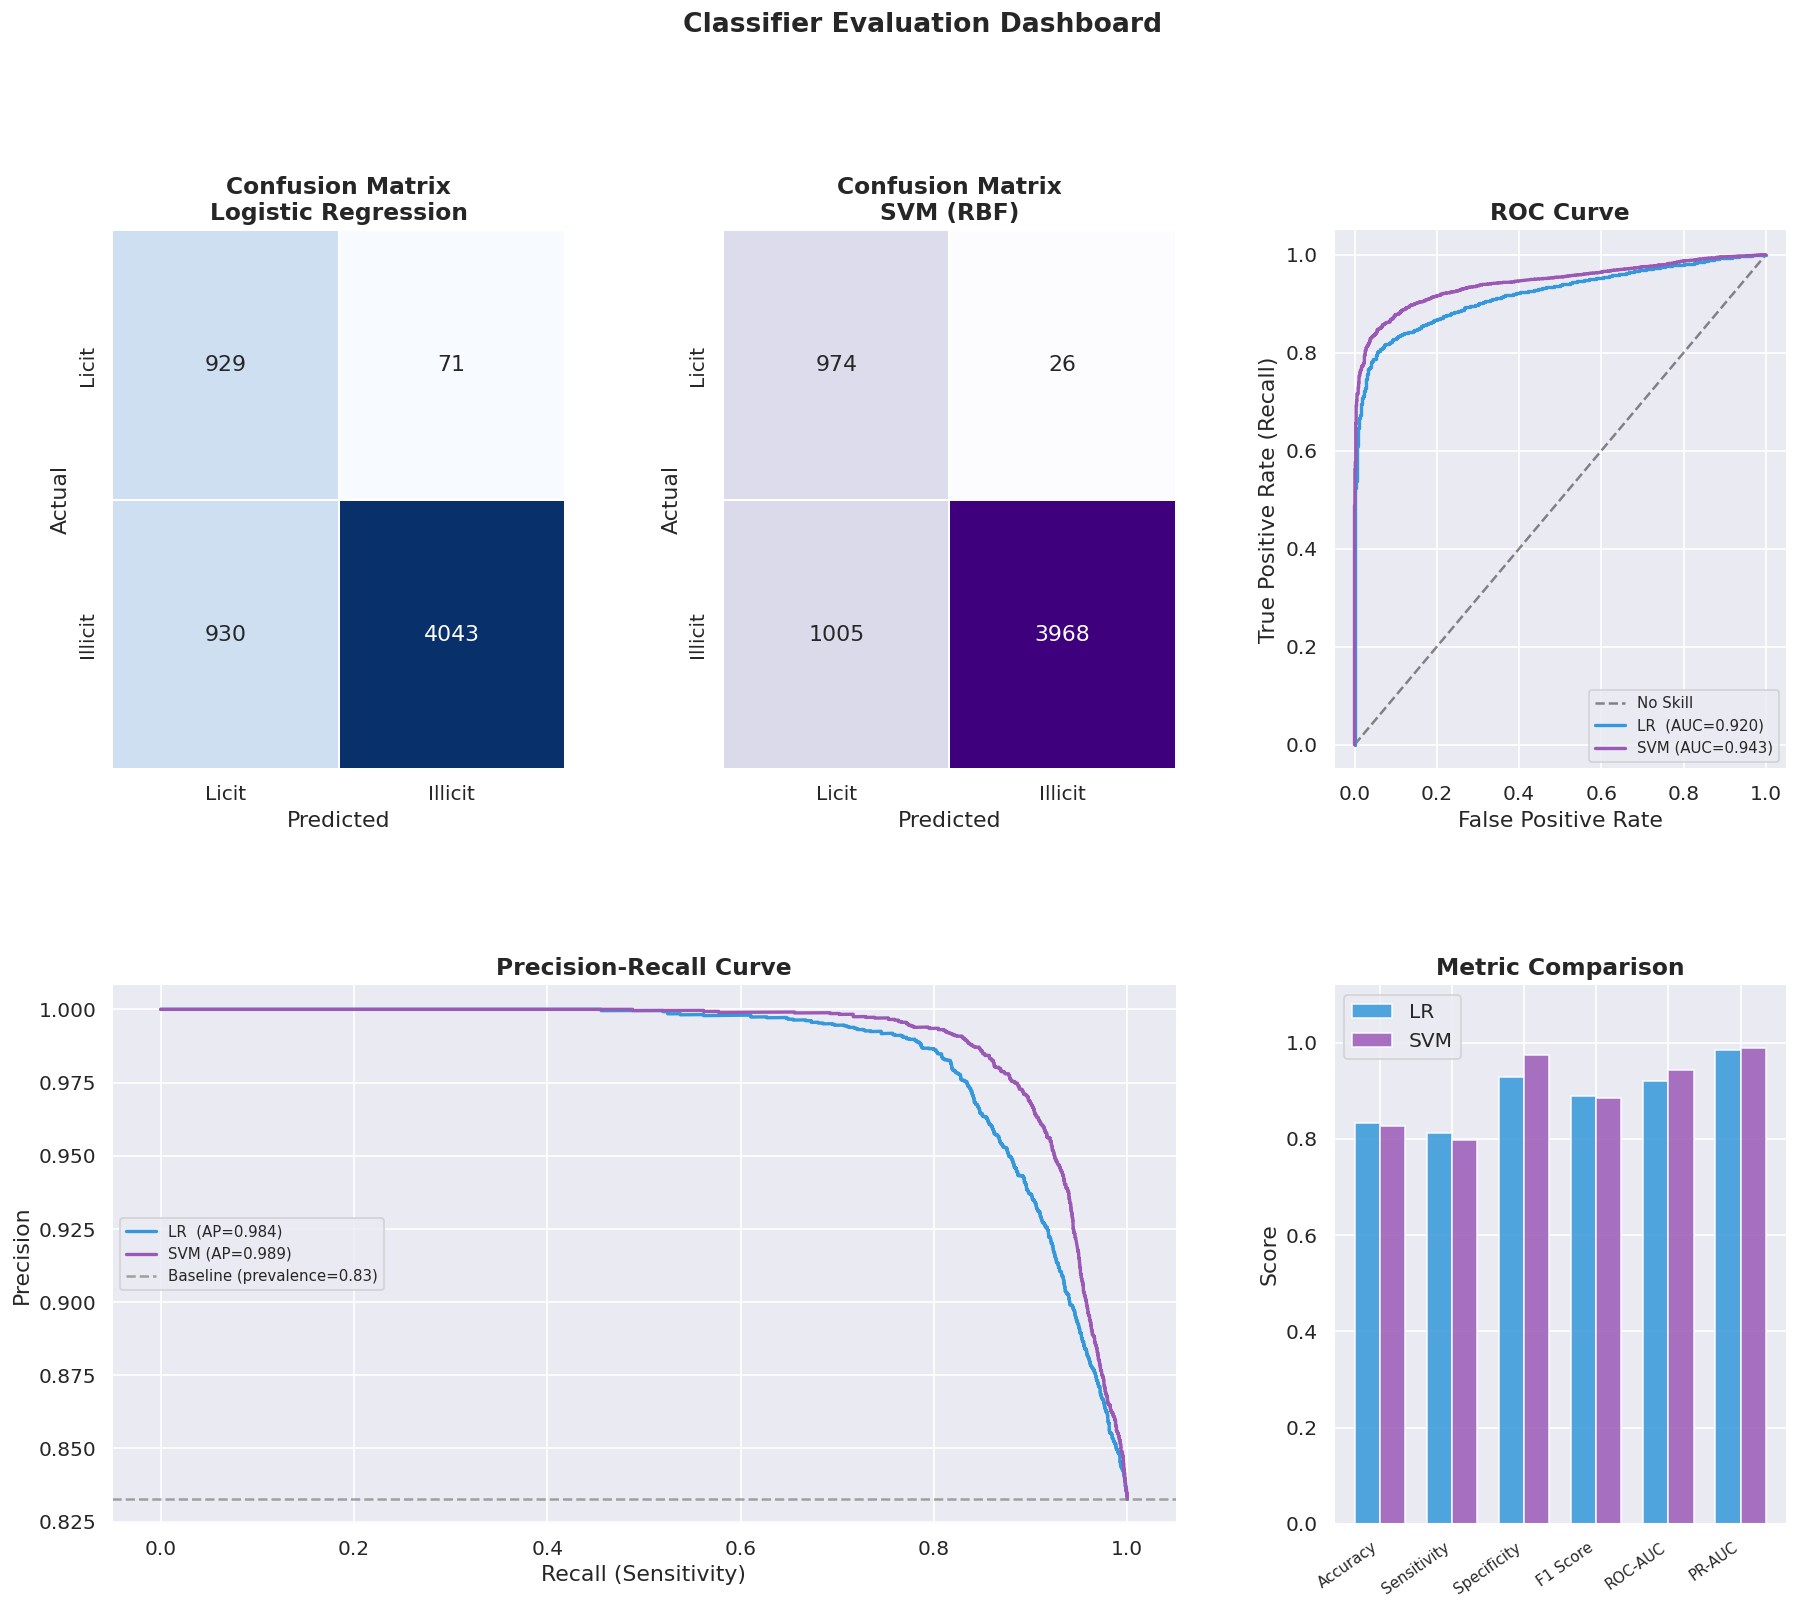

In [26]:
# ── Visual Evaluation Dashboard ───────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
fig.suptitle("Classifier Evaluation Dashboard", fontsize=16, fontweight='bold', y=1.01)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# --- Confusion matrices ---
for idx, (cm, name, color) in enumerate([(cm_lr, "Logistic Regression", "Blues"),
                                          (cm_svm, "SVM (RBF)",          "Purples")]):
    ax = fig.add_subplot(gs[0, idx])
    sns.heatmap(cm, annot=True, fmt='d', cmap=color, ax=ax,
                xticklabels=['Licit', 'Illicit'], yticklabels=['Licit', 'Illicit'],
                linewidths=1, linecolor='white', cbar=False)
    ax.set_title(f"Confusion Matrix\n{name}", fontweight='bold')
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")

# --- ROC Curves ---
ax_roc = fig.add_subplot(gs[0, 2])
ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='No Skill')
for proba, name, color in [(proba_lr, f"LR  (AUC={m_lr['ROC-AUC']:.3f})",  '#3498db'),
                            (proba_svm,f"SVM (AUC={m_svm['ROC-AUC']:.3f})", '#9b59b6')]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax_roc.plot(fpr, tpr, label=name, linewidth=2, color=color)
ax_roc.set_title("ROC Curve", fontweight='bold')
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate (Recall)")
ax_roc.legend(fontsize=9)
sns.despine(ax=ax_roc)

# --- Precision-Recall Curves ---
ax_pr = fig.add_subplot(gs[1, 0:2])
for proba, name, color in [(proba_lr, f"LR  (AP={m_lr['PR-AUC']:.3f})",   '#3498db'),
                            (proba_svm,f"SVM (AP={m_svm['PR-AUC']:.3f})",  '#9b59b6')]:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ax_pr.plot(rec, prec, label=name, linewidth=2, color=color)
ax_pr.axhline(y_test.mean(), color='gray', linestyle='--', alpha=0.7,
              label=f"Baseline (prevalence={y_test.mean():.2f})")
ax_pr.set_title("Precision-Recall Curve", fontweight='bold')
ax_pr.set_xlabel("Recall (Sensitivity)")
ax_pr.set_ylabel("Precision")
ax_pr.legend(fontsize=9)
sns.despine(ax=ax_pr)

# --- Metric Comparison Bar Chart ---
ax_bar = fig.add_subplot(gs[1, 2])
metrics_to_compare = ["Accuracy", "Sensitivity", "Specificity", "F1 Score", "ROC-AUC", "PR-AUC"]
x = np.arange(len(metrics_to_compare))
width = 0.35
vals_lr  = [m_lr[m]  for m in metrics_to_compare]
vals_svm = [m_svm[m] for m in metrics_to_compare]
ax_bar.bar(x - width/2, vals_lr,  width, label='LR',  color='#3498db', alpha=0.85)
ax_bar.bar(x + width/2, vals_svm, width, label='SVM', color='#9b59b6', alpha=0.85)
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(metrics_to_compare, rotation=35, ha='right', fontsize=9)
ax_bar.set_ylim(0, 1.12)
ax_bar.set_title("Metric Comparison", fontweight='bold')
ax_bar.legend()
ax_bar.set_ylabel("Score")
sns.despine(ax=ax_bar)

plt.tight_layout()
plt.show()

<a id='11'></a>
## 1️⃣1️⃣ Key Takeaways & Next Steps

### Summary

This notebook demonstrated a complete **semi-supervised fraud detection pipeline** on the Elliptic Bitcoin dataset:

| Step | What we did | Why it matters |
|------|-------------|----------------|
| **Data Engineering** | Handled `unknown` labels with proportional pseudo-labelling | Preserves dataset size & real class ratio |
| **Autoencoder** | Trained exclusively on licit transactions | Learns a "normal behaviour" manifold |
| **Latent Space** | Extracted 50-d representations | Richer, separable features |
| **t-SNE** | Before/after comparison | Visualises improved separability |
| **Multi-metric Eval** | Accuracy + Sensitivity + Specificity + ROC/PR-AUC | Avoids misleading accuracy on imbalanced data |

---

### Potential Improvements

1. **Graph Neural Networks (GNNs)** — The edge list (`elliptic_txs_edgelist.csv`) encodes money flow between wallets. A GNN (e.g., Graph Sage, GAT) can exploit this structural information, significantly boosting detection power.

2. **Variational Autoencoder (VAE)** — A probabilistic variant that learns a smoother latent distribution, enabling anomaly scoring via the ELBO.

3. **Threshold tuning** — Instead of defaulting to 0.5, tune the classification threshold to optimise for F2 or precision@recall.

4. **Temporal modelling** — The time step feature could feed an LSTM or Transformer encoder to capture evolving fraud patterns.

5. **SHAP / Explainability** — Apply SHAP values on the latent representation to understand which original features drive the illicit/licit distinction — important for regulatory contexts.

---

### References

- Pareja et al. (2020). *EvolveGCN: Evolving Graph Convolutional Networks for Dynamic Graphs.* AAAI.
- Weber et al. (2019). *Anti-Money Laundering in Bitcoin: Experimenting with Graph Convolutional Networks.* KDD Workshop.
- [Elliptic Dataset on Kaggle](https://www.kaggle.com/ellipticco/elliptic-data-set)
- [t-SNE Original Paper (van der Maaten & Hinton, 2008)](https://lvdmaaten.github.io/publications/papers/JMLR_2008.pdf)


